# CASM Pulsar Search Walkthrough

From beam-dump `.dat` files to a pdmp SNR measurement. Picks up where `casm_calibration_beamforming_walkthrough.ipynb` ends (BF weights uploaded -> beams being dumped to disk).

**Test case**: B0329+54 daytime transit, 2026-05-16. Best beam (BEAM 2) reached prepfold chi^2=2.14 (5.6 sigma) / pdmp SNR=9.1 - about 9x below paper-radiometer ideal due to daytime + Sun-cal-distant + pointing offset.

**Apptainer images used:**
- presto5: `/home/casm/software/vishnu/apptainer_images/presto5_latest.sif` (`prepfold`, `prepdata`, `rfifind`, `readfile`)
- pulsarx: `/home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif` (`filtool`)
- psrtools: `/home/casm/software/vishnu/apptainer_images/psrtools_latest.sif` (`dspsr`, `pdmp`)

Run shell commands via `subprocess` inside cells.

**This notebook uses pre-existing converted/cleaned .fil files** from the FINAL workspace (`/home/casm/B0329_2026_05_16_FINAL/`). The slow conversion + filtool stages are shown as commands but not re-run; downstream prepfold / dspsr / pdmp are run on the existing inputs for real outputs.


In [1]:
import os, re, struct, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)

SIF_PRESTO = '/home/casm/software/vishnu/apptainer_images/presto5_latest.sif'
SIF_PULSARX = '/home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif'
SIF_PSRTOOLS = '/home/casm/software/vishnu/apptainer_images/psrtools_latest.sif'

# Per-obs paths
WORKDIR = '/home/casm/B0329_2026_05_16_FINAL'
DUMP_GLOB = '/mnt/nvme4/data/casm/beam_dumps/beam_0-63_2026-05-16-18:40:26.dat.*'
PAR = f'{WORKDIR}/B0329+54.par'
BEAMS = [0, 1, 2, 3, 4]   # 4 source + 1 control

# Notebook demo paths (already exist)
LIVE = f'{WORKDIR}/fil_liveband'
SCRATCH = '/tmp/casm_pulsar_demo'
Path(SCRATCH).mkdir(parents=True, exist_ok=True)
print(f'WORKDIR exists: {os.path.isdir(WORKDIR)}, BEAM2 clean fil exists: {os.path.exists(f"{LIVE}/BEAM2_clean_01.fil")}')


WORKDIR exists: True, BEAM2 clean fil exists: True


## section 1 - Beam dump -> filterbank

Pull one beam at a time out of the 64-beam dump and write as sigproc filterbank.

**Gotcha**: 4-way parallel conversion can OOM on long obs (each process holds the full 4D array in memory). Use 2-at-a-time, or sequential. Today's 5h 22min × 22 GB per process = ~80 GB peak with 4-parallel; 2-parallel is safer.

This cell is illustrative only - the .fil files have already been generated and live at `/home/casm/B0329_2026_05_16_FINAL/fil/`.


In [2]:
# Single-beam conversion (offline / safe for long obs)
PY = '/home/casm/software/dev/casm_venvs/casm_offline_env/bin/python'
SCRIPT = '/home/casm/software/vishnu/BEAM_TESTS/casm_combine_time_contigous_multi_beam_dump_to_sigproc.py'

print('Conversion commands (illustrative - NOT run; .fil files already exist):')
for ib in BEAMS:
    out = f'{WORKDIR}/fil/20260516_BEAM{ib}.fil'
    cmd = (
        f'{PY} {SCRIPT} '
        f'--infile $(ls -v {DUMP_GLOB}) '
        f'--ibeam {ib} --outfile {out}'
    )
    print(f'  BEAM {ib}: {cmd[:120]}...')
    # subprocess.run(cmd, shell=True, check=True)   # NOT RUN in notebook

# Verify existing output
existing = sorted(Path(f'{WORKDIR}/fil').glob('20260516_BEAM*.fil'))
print(f'\nExisting filterbank files: {len(existing)}')
for p in existing[:5]:
    sz_gb = p.stat().st_size / 1e9
    print(f'  {p.name}  ({sz_gb:.1f} GB)')


Conversion commands (illustrative - NOT run; .fil files already exist):
  BEAM 0: /home/casm/software/dev/casm_venvs/casm_offline_env/bin/python /home/casm/software/vishnu/BEAM_TESTS/casm_combine_time_c...
  BEAM 1: /home/casm/software/dev/casm_venvs/casm_offline_env/bin/python /home/casm/software/vishnu/BEAM_TESTS/casm_combine_time_c...
  BEAM 2: /home/casm/software/dev/casm_venvs/casm_offline_env/bin/python /home/casm/software/vishnu/BEAM_TESTS/casm_combine_time_c...
  BEAM 3: /home/casm/software/dev/casm_venvs/casm_offline_env/bin/python /home/casm/software/vishnu/BEAM_TESTS/casm_combine_time_c...
  BEAM 4: /home/casm/software/dev/casm_venvs/casm_offline_env/bin/python /home/casm/software/vishnu/BEAM_TESTS/casm_combine_time_c...

Existing filterbank files: 5
  20260516_BEAM0.fil  (57.0 GB)
  20260516_BEAM1.fil  (57.0 GB)
  20260516_BEAM2.fil  (57.0 GB)
  20260516_BEAM3.fil  (57.0 GB)
  20260516_BEAM4.fil  (57.0 GB)


## section 2 - Inspect filterbank

Quick header + per-channel stats check. **Key thing to look at**: what fraction of channels are zero (cal's drop-bad-channels strategy). This decides whether to use live-band slice (section 3 Path A) or full-band (section 3 Path B).


In [3]:
# readfile (presto): header summary on the cleaned BEAM 2 file
fil = f'{LIVE}/BEAM2_clean_01.fil'
out = subprocess.check_output(
    f'apptainer exec {SIF_PRESTO} readfile {fil}', shell=True
).decode()
for line in out.splitlines():
    if any(k in line for k in ['Telescope', 'Source', 'MJD', 'Sample time', 'channels', 'Bandwidth', 'Beam']):
        print(line)


                  Telescope = Fake
                Source Name = PSRJ0332+5434
             MJD start time = 61176.80353036818997
           Sample time (us) = 4194.304         
         Number of channels = 812
      Total Bandwidth (MHz) = 24.7802734375    
                       Beam = 2 of 1
            Beam FWHM (deg) = 1.000


In [4]:
# Per-channel stats via `your` (in offline venv). Uses a small mid-obs slice.
PY_OFFLINE = '/home/casm/software/dev/casm_venvs/casm_offline_env/bin/python'
inspect_cmd = f'''{PY_OFFLINE} -c "
import numpy as np
from your import Your
y = Your('{fil}')
h = y.your_header
print(f'nchans={{h.nchans}}  nbits={{h.nbits}}  tsamp={{h.tsamp*1e6:.1f}}us  T_obs={{h.nspectra*h.tsamp/3600:.2f}}h')
sample = y.get_data(int(h.nspectra * 0.5), 4096)
chan_std = sample.std(axis=0)
chan_mean = sample.mean(axis=0)
dead_frac = (chan_std < 1e-6).sum() / h.nchans
print(f'dead fraction: {{dead_frac:.1%}}  ({{(chan_std < 1e-6).sum()}}/{{h.nchans}} chans)')
print(f'per-chan mean: min={{chan_mean.min():.3f}}  median={{np.median(chan_mean):.3f}}  max={{chan_mean.max():.3f}}')
print(f'per-chan std:  min={{chan_std.min():.4f}}  median={{np.median(chan_std):.4f}}  max={{chan_std.max():.4f}}')
"
'''
out = subprocess.check_output(inspect_cmd, shell=True, stderr=subprocess.STDOUT).decode()
print(out)


nchans=812  nbits=32  tsamp=4194.3us  T_obs=1.64h
dead fraction: 7.3%  (59/812 chans)
per-chan mean: min=-0.025  median=0.000  max=0.008
per-chan std:  min=0.0000  median=0.9987  max=1.0052



## section 3 - Live-band slice (OPTIONAL)

**This is optional.** Decision rule based on section 2:

| Dead chan fraction | Recommendation |
|---|---|
| **> 50%** (today's regime) | **Path A**: slice to live-band - chans 631-1442 (440-465 MHz), 812 chans output |
| 10-50% | Path B with `--zapthre -1` in filtool |
| < 10% (future, when cal recovers more chans) | Path B with default filtool params |

### Path A: header-copy slicer (live-band only)

**Why header-copy**: writing a fresh sigproc header (e.g. via `your.formats.filwriter`) produces fields filtool can't parse. Reading the original header bytes and patching just `nchans` and `fch1` keeps everything compatible.


In [5]:
# Live-band slicer (header-copy)
def read_sigproc_header(fp):
    raw = b''; hdr = {}
    while True:
        kb = fp.read(4); raw += kb
        kl = struct.unpack('<I', kb)[0]
        kbytes = fp.read(kl); raw += kbytes
        k = kbytes.decode('ascii')
        if k == 'HEADER_START': continue
        if k == 'HEADER_END': break
        if k in ('rawdatafile', 'source_name'):
            vlb = fp.read(4); raw += vlb
            vl = struct.unpack('<I', vlb)[0]
            v = fp.read(vl); raw += v; hdr[k] = v.decode('ascii')
        elif k in ('machine_id','telescope_id','data_type','barycentric','pulsarcentric',
                   'nbits','nsamples','nchans','nifs','scan_number','ibeam','nbeams'):
            vb = fp.read(4); raw += vb; hdr[k] = struct.unpack('<i', vb)[0]
        else:
            vb = fp.read(8); raw += vb; hdr[k] = struct.unpack('<d', vb)[0]
    return raw, hdr

def patch_int(r, k, v):
    p = struct.pack('<I', len(k)) + k.encode(); i = r.find(p); s = i + len(p)
    return r[:s] + struct.pack('<i', v) + r[s+4:]

def patch_dbl(r, k, v):
    p = struct.pack('<I', len(k)) + k.encode(); i = r.find(p); s = i + len(p)
    return r[:s] + struct.pack('<d', v) + r[s+8:]

def slice_to_liveband(input_fil, output_fil, c_lo=631, c_hi=1443):
    with open(input_fil, 'rb') as fp:
        raw, hdr = read_sigproc_header(fp); hsz = fp.tell()
    nb = hdr['nbits']
    new_fch1 = hdr['fch1'] + c_lo * hdr['foff']
    new_hdr = patch_int(raw, 'nchans', c_hi - c_lo)
    new_hdr = patch_dbl(new_hdr, 'fch1', new_fch1)
    bps = (nb // 8) * hdr['nchans']
    nsamp = (os.path.getsize(input_fil) - hsz) // bps
    dt = {8: np.uint8, 16: np.int16, 32: np.float32}[nb]
    with open(input_fil, 'rb') as fi, open(output_fil, 'wb') as fo:
        fi.seek(hsz); fo.write(new_hdr)
        written = 0
        while written < nsamp:
            n = min(65536, nsamp - written)
            arr = np.frombuffer(fi.read(n*bps), dtype=dt).reshape(n, hdr['nchans'])
            fo.write(np.ascontiguousarray(arr[:, c_lo:c_hi]).tobytes())
            written += n
    return output_fil

print('slice_to_liveband() is defined; live-band .fil files have already been produced and live in fil_liveband/.')
existing_lb = sorted(Path(LIVE).glob('20260516_BEAM*_FULL_liveband_*.fil'))
for p in existing_lb[:5]:
    print(f'  {p.name}  ({p.stat().st_size/1e9:.2f} GB)')


slice_to_liveband() is defined; live-band .fil files have already been produced and live in fil_liveband/.
  20260516_BEAM0_FULL_liveband_440-465MHz.fil  (15.05 GB)
  20260516_BEAM1_FULL_liveband_440-465MHz.fil  (15.05 GB)
  20260516_BEAM2_FULL_liveband_440-465MHz.fil  (15.05 GB)
  20260516_BEAM3_FULL_liveband_440-465MHz.fil  (15.05 GB)
  20260516_BEAM4_FULL_liveband_440-465MHz.fil  (15.05 GB)


### Path B: full band (no slice)

If you skip the slice, pass `--zapthre -1` to filtool in section 4 to disable its broken IQR filter (it fails when > ~30% of channels have zero variance - the IQR Q1/Q3 both collapse to FLOAT_MAX which makes the live channels look like outliers and get zeroed).

When future cal improvements bring the dead fraction below ~10%, you can drop `--zapthre -1` and use defaults.


## section 4 - Clean with filtool

**filtool RFI flags (`-z`):**

| Flag | What it does | When to use |
|------|--------------|-------------|
| **`-z kadaneF 8 4`** (recommended) | Frequency-domain Kadane filter | Default; catches narrow-band carriers |
| `-z mask 10 4` | S/N-threshold time x freq block mask | Alongside kadaneF for impulsive RFI |
| `-z kadaneT 7 4` | Time-domain Kadane | **Not well tested** - skip |
| `-z zdot` | Zero-DM subtractor | **Kills DM<30 pulsars** (B0329 has DM=27) |
| `-z zap fl fh` | Zap a freq range | Known RFI bands |

**Output normalization (`--mean / --std`):**

| nbits | mean | std | Use |
|------:|-----:|----:|-----|
| **`32`** (recommended) | `0` | `1` | Float; no quantization loss |
| `8` | `128` | `6` | Compact; 8-bit unsigned with headroom |

**`--baseline N`** (running-median per-channel DC removal, seconds):

| Value | Behavior |
|------:|----------|
| **`8`** (recommended for B0329-class) | >> pulse period, captures slow drift |
| `30` | Gentler; use if `8` eats the pulsar |
| `0` or `< 3 tsamp` | Disabled |

**Telescope**: always pass `--telescope GBT` (or any TEMPO-recognized name) so dspsr/pdmp tempo lookups work later.

This cell is illustrative - filtool outputs already exist as `BEAM{ib}_clean_01.fil` files in `fil_liveband/`.


In [6]:
# filtool - clean recipe (live-band input, Path A from section 3)
for ib in BEAMS:
    src = f'{LIVE}/20260516_BEAM{ib}_FULL_liveband_440-465MHz.fil'
    cmd = (
        f'apptainer exec {SIF_PULSARX} filtool '
        f'--telescope GBT --source_name PSRJ0332+5434 '
        f'--ra 03:32:59.4096 --dec +54:34:43.329 '
        f'--nbits 32 --mean 0 --std 1 '
        f'--baseline 8 '
        f'-z kadaneF 8 4 '
        f'-t 4 '
        f'-o {LIVE}/BEAM{ib}_FULL_clean '
        f'-f {src}'
    )
    print(f'BEAM {ib}: {cmd[:100]}...')
    # subprocess.run(cmd, shell=True, check=True)   # NOT RUN in notebook

# Verify outputs
for ib in BEAMS:
    p = Path(f'{LIVE}/BEAM{ib}_FULL_clean_01.fil')
    if p.exists():
        print(f'  BEAM {ib} clean fil: {p.stat().st_size/1e9:.1f} GB')

# For Path B (full-band, no slice), add: --zapthre -1
# Skip -z zdot for low-DM pulsars (B0329 DM=27)


BEAM 0: apptainer exec /home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif filtool --telescope GB...
BEAM 1: apptainer exec /home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif filtool --telescope GB...
BEAM 2: apptainer exec /home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif filtool --telescope GB...
BEAM 3: apptainer exec /home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif filtool --telescope GB...
BEAM 4: apptainer exec /home/casm/software/vishnu/apptainer_images/pulsarx_latest.sif filtool --telescope GB...
  BEAM 0 clean fil: 15.1 GB
  BEAM 1 clean fil: 15.1 GB
  BEAM 2 clean fil: 15.1 GB
  BEAM 3 clean fil: 15.1 GB
  BEAM 4 clean fil: 15.1 GB


## section 5 - Build phase predictor

**Why we need this**: dspsr's `-E par.txt` invokes tempo2 internally to generate polycos. tempo2 fails with `error code 1` if the telescope (`Fake` or `OVRO`) isn't in its observatory database. The simple text predictor below bypasses tempo2 entirely.

**EPOCH**: per-beam (each beam's .fil has its own MJD start; for a windowed .fil this differs from the full obs start).


In [7]:
# Build per-beam predictor file from each .fil's tstart
PAR_PERIOD = 0.7145295183   # 1/F0 from par (tune to converged best period)
PAR_DM     = 26.76410
PAR_RA     = '03:32:59.4096'
PAR_DEC    = '+54:34:43.329'

# Demo: build a predictor for BEAM 2 from its cleaned .fil header.
fil = f'{LIVE}/BEAM2_clean_01.fil'
out = subprocess.check_output(f'apptainer exec {SIF_PRESTO} readfile {fil}', shell=True).decode()
m = re.search(r'MJD start time\s*=\s*(\S+)', out)
mjd = m.group(1) if m else None
pred = f'{SCRATCH}/B0329+54_BEAM2_predictor.txt'
with open(pred, 'w') as fh:
    fh.write(f'SOURCE: J0332+5434\n')
    fh.write(f'EPOCH: {mjd}\n')
    fh.write(f'PERIOD: {PAR_PERIOD} s\n')
    fh.write(f'DM: {PAR_DM}\n')
    fh.write(f'ACC: 0\n')
    fh.write(f'RA: {PAR_RA}\n')
    fh.write(f'DEC: {PAR_DEC}\n')
print(f'BEAM 2 predictor written to {pred}  (EPOCH={mjd})')
with open(pred) as fh:
    print(fh.read())


BEAM 2 predictor written to /tmp/casm_pulsar_demo/B0329+54_BEAM2_predictor.txt  (EPOCH=61176.80353036818997)
SOURCE: J0332+5434
EPOCH: 61176.80353036818997
PERIOD: 0.7145295183 s
DM: 26.7641
ACC: 0
RA: 03:32:59.4096
DEC: +54:34:43.329



## section 6 - prepfold

**Key flags & recommendations:**

| Flag | What it does | When to use |
|------|--------------|-------------|
| **`-topo`** (recommended for CASM) | Topocentric fold (no bary correction) | Our filterbank is already topo |
| `-noxwin` | No X | Always |
| **`-slow`** (recommended for P > 100 ms) | More profile bins (100), smaller DM search | B0329's narrow 6.6 ms pulse needs 100 bins |
| **`-nodmsearch`** (recommended when DM is known) | Lock DM | Saves cycles, prevents RFI at DM=0 |
| **`-nsub 29`** (recommended for 812-chan live band) | 29 sub-bands x 28 chans/sub | Clean divisor; visible freq-phase structure |
| `-nsub 64`/`128` | Standard | For full 3072-chan data |
| `-start <frac>` `-end <frac>` | Fold window (fractions of T_obs) | Pick source-in-beam |
| `-mask <mask>` | rfifind mask | NOT needed when filtool cleaned |

**Gotcha**: prepfold often fails with "Cannot automatically determine a good value for -nsub: Success" - always pass `-nsub` explicitly with a clean divisor of `nchan`.

For the demo run below we use a **1-minute slice** of BEAM 2 so prepfold completes in seconds.


In [8]:
# Demo prepfold on a short slice of BEAM 2 (so it runs fast inside the notebook).
fil = f'{LIVE}/BEAM2_clean_01.fil'
# 1-minute slice: ~5910 s total -> start fraction 0.38, end fraction 0.398 (~1 min around mid-obs)
sf, ef = 0.380, 0.398

prepfold_out_base = f'{SCRATCH}/BEAM2_demo_fold'
cmd = (
    f'apptainer exec {SIF_PRESTO} prepfold '
    f'-noxwin -topo -slow -par {PAR} '
    f'-nodmsearch -nsub 29 '
    f'-start {sf} -end {ef} '
    f'-o {prepfold_out_base} {fil}'
)
print('Running:', cmd[:120], '...')
result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=600)
print('stdout tail:', result.stdout.splitlines()[-5:] if result.stdout else '(empty)')
print('returncode:', result.returncode)

# Find produced .pfd*
produced = sorted(Path(SCRATCH).glob('BEAM2_demo_fold*.pfd*'))
for p in produced:
    print(f'  {p.name}  ({p.stat().st_size} bytes)')


Running: apptainer exec /home/casm/software/vishnu/apptainer_images/presto5_latest.sif prepfold -noxwin -topo -slow -par /home/ca ...


stdout tail: ['', 'Effective number of DOF = 79.36', 'Off-pulse Reduced chi^2 correction factor = 1.03', 'Done.', '']
returncode: 0
  BEAM2_demo_fold_PSR_0332+5434.pfd  (253484 bytes)
  BEAM2_demo_fold_PSR_0332+5434.pfd.bestprof  (2484 bytes)
  BEAM2_demo_fold_PSR_0332+5434.pfd.png  (214753 bytes)
  BEAM2_demo_fold_PSR_0332+5434.pfd.polycos  (33912 bytes)
  BEAM2_demo_fold_PSR_0332+5434.pfd.ps  (398431 bytes)


demo: # Epoch_topo       =  61176.829511751304
demo: # Epoch_bary       =  N/A
demo: # Reduced chi-sqr  =  1.800
demo: # Best DM          =  26.715

Demo 1-min slice prepfold output:


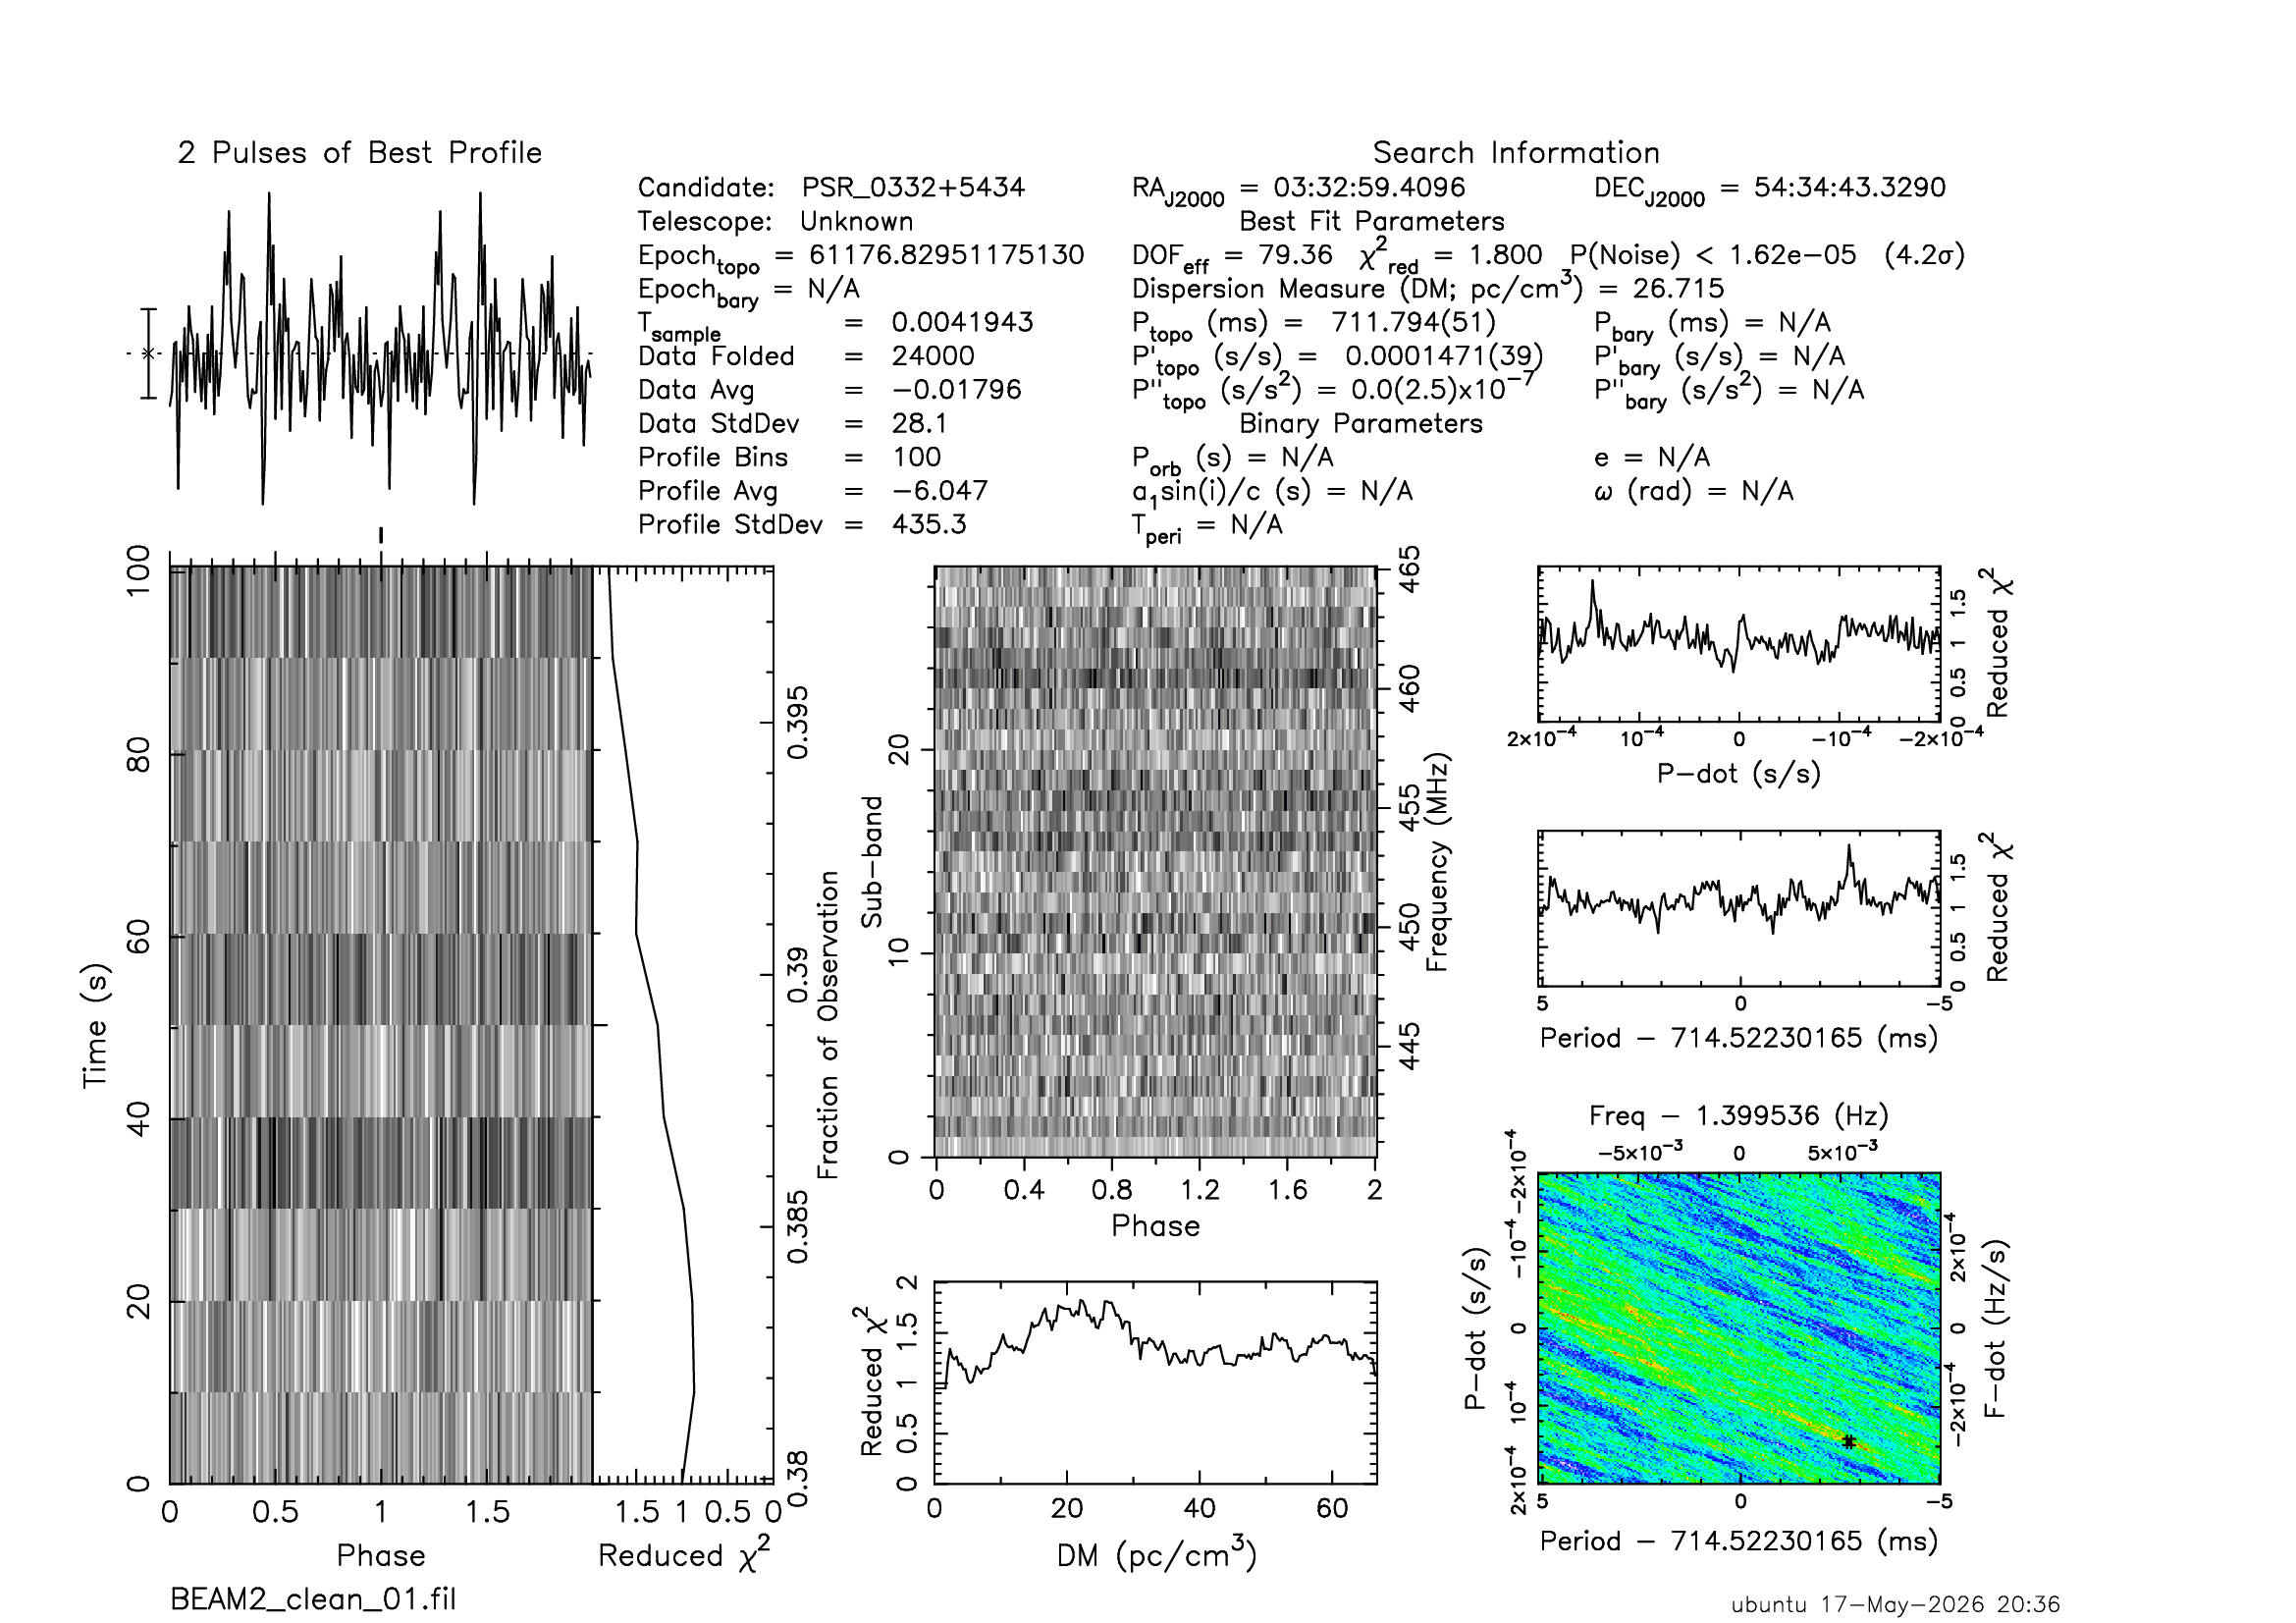


Production full-window BEAM 2 fold (5h22 of data):


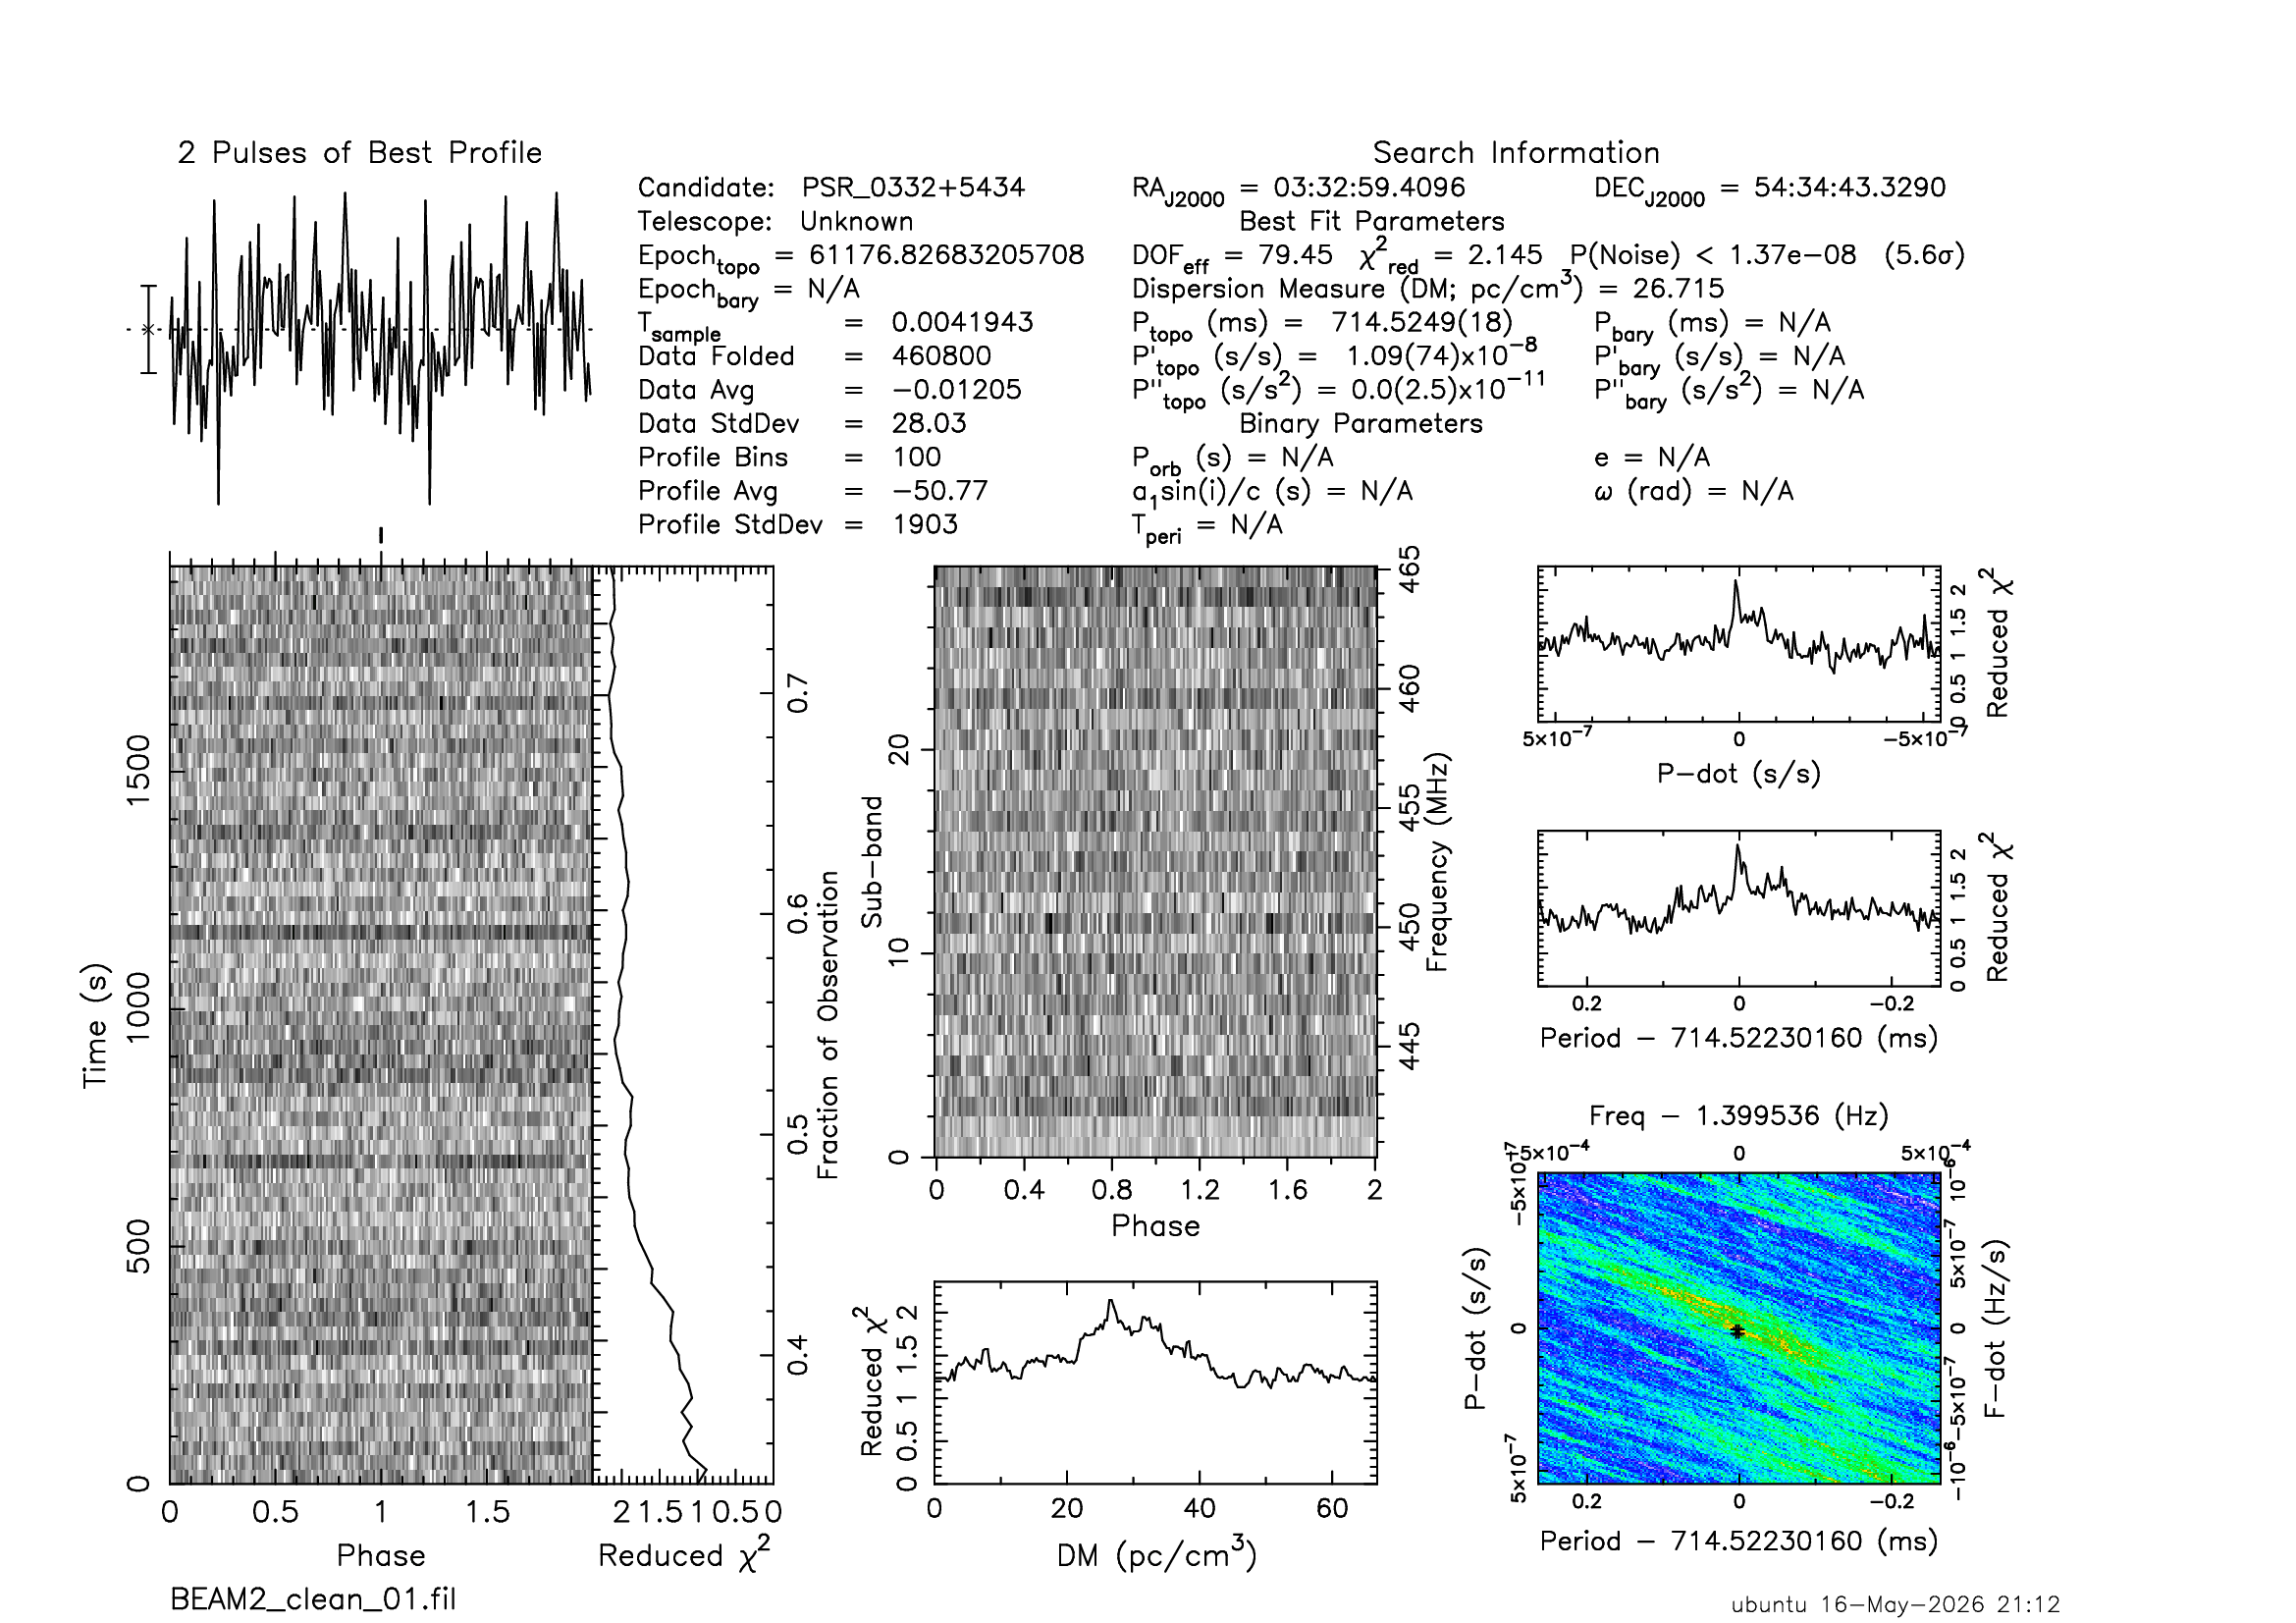

In [9]:
# Display the prepfold PNG output (if produced) and the bestprof chi-sq value
demo_png = next(Path(SCRATCH).glob('BEAM2_demo_fold*.pfd.png'), None)
demo_bp  = next(Path(SCRATCH).glob('BEAM2_demo_fold*.pfd.bestprof'), None)

# Also show one of the production-quality full-window folds for context
prod_png = Path(f'{WORKDIR}/folds_FINAL/BEAM2_BEST_predicted_chi2.145.png')

if demo_bp and demo_bp.exists():
    with open(demo_bp) as f:
        for line in f:
            if 'Reduced chi-sqr' in line or 'Best DM' in line or 'Epoch' in line:
                print('demo:', line.rstrip())

if demo_png and demo_png.exists():
    print('\nDemo 1-min slice prepfold output:')
    display(Image(filename=str(demo_png), width=600))
if prod_png.exists():
    print('\nProduction full-window BEAM 2 fold (5h22 of data):')
    display(Image(filename=str(prod_png), width=600))


## section 7 - dspsr + pdmp

**dspsr flags:**

| Flag | What it does | When to use |
|------|--------------|-------------|
| **`-W`** (MANDATORY) | Disable per-sample weights | Always for our sigproc-only data (fixes `ndat_per_weight=0`) |
| **`-set site=GBT`** (recommended) | Override telescope | Filtool wrote `Fake` or unrecognized telescope |
| **`-P <predictor>`** (recommended) | Pre-built predictor | Bypasses tempo2 telescope failure |
| `-L <s>` | Subintegration length | Power-of-2 x period for clean fold |
| `-A` | Single archive with multi subints | Default for us |

**pdmp flags:**

| Flag | What it does |
|------|--------------|
| `-mc 29` | Max channels (= nsub used in dspsr) |
| `-ms <N>` | Max subints |
| `-mb 100` | Max profile bins |
| `-g <name>.png/PNG` | PGPLOT output (PNG device) |


In [10]:
# Demo dspsr + pdmp on a short slice of BEAM 2 (uses the predictor we built above).
pred = f'{SCRATCH}/B0329+54_BEAM2_predictor.txt'
archive_base = f'{SCRATCH}/BEAM2_demo_dspsr'

# dspsr: window via -S (seek seconds) + -T (duration seconds). 60s slice keeps it fast.
cmd_dspsr = (
    f'apptainer exec {SIF_PSRTOOLS} dspsr '
    f'-W -set site=GBT -P {pred} '
    f'-L 4 -Lmin 1 -A '
    f'-S 2200 -T 60 '
    f'-O {archive_base} {LIVE}/BEAM2_clean_01.fil'
)
print('Running dspsr...')
r = subprocess.run(cmd_dspsr, shell=True, capture_output=True, text=True, timeout=600)
print('dspsr returncode:', r.returncode)
if r.returncode != 0:
    print('stderr:', r.stderr[-400:])

ar_path = f'{archive_base}.ar'
print(f'archive exists: {os.path.exists(ar_path)}')


Running dspsr...


dspsr returncode: 0
archive exists: True


In [11]:
# pdmp: small DM search around known DM, max 15 subints
ar_path = f'{SCRATCH}/BEAM2_demo_dspsr.ar'
png_path = f'{SCRATCH}/BEAM2_demo_dspsr.png'
log_path = f'{SCRATCH}/BEAM2_demo_pdmp.log'

if os.path.exists(ar_path):
    cmd_pdmp = (
        f'apptainer exec {SIF_PSRTOOLS} pdmp '
        f'-mc 29 -ms 15 -mb 100 '
        f'-g {png_path}/PNG {ar_path}'
    )
    print('Running pdmp...')
    r = subprocess.run(cmd_pdmp, shell=True, capture_output=True, text=True, timeout=300)
    print('pdmp returncode:', r.returncode)
    with open(log_path, 'w') as fh:
        fh.write(r.stdout)
        fh.write('\n---STDERR---\n')
        fh.write(r.stderr)
    # Print key pdmp lines
    for line in (r.stdout or '').splitlines():
        if 'Best' in line or 'S/N' in line or 'DM' in line:
            print('  ', line)
else:
    print('Archive missing; skipping pdmp.')


Running pdmp...


pdmp returncode: 0
   Searching for optimum DM and Period...
    DM: 118   P1: 0   P0: 18
   Best S/N = 4.88
   BC Period (ms) = 714.5188226  TC Period (ms) =  714.5295183  DM =   26.7641
   Best BC Period (ms) = 713.9331313  Correction (ms) = -0.5856912847  Error (ms) = 0.1567499245
   Best TC Period (ms) = 713.9438182  Correction (ms) = -0.585700052  Error (ms) = 0.1567499245
   Best DM =    7.7481  Correction = -19.02  Error = 5.01
   Best BC Frequency (Hz) = 1.400691404  Error (Hz) = 0.000307533384
   Best Pdot =   0 s/s
   Best Accn =   0 m/s


Production pdmp results (full 5h22 windows, run earlier in the campaign):

BEAM 0:


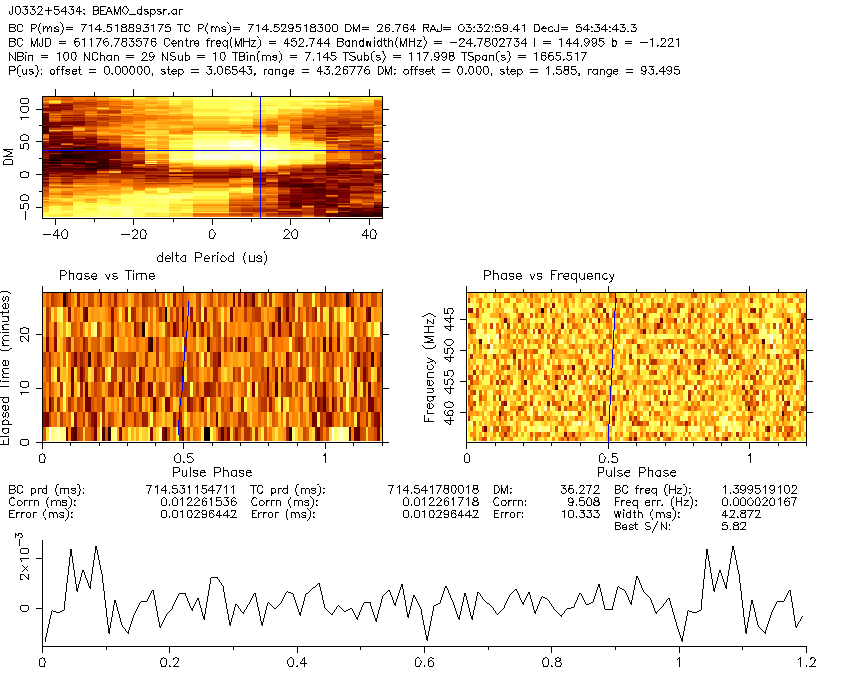

BEAM 1:


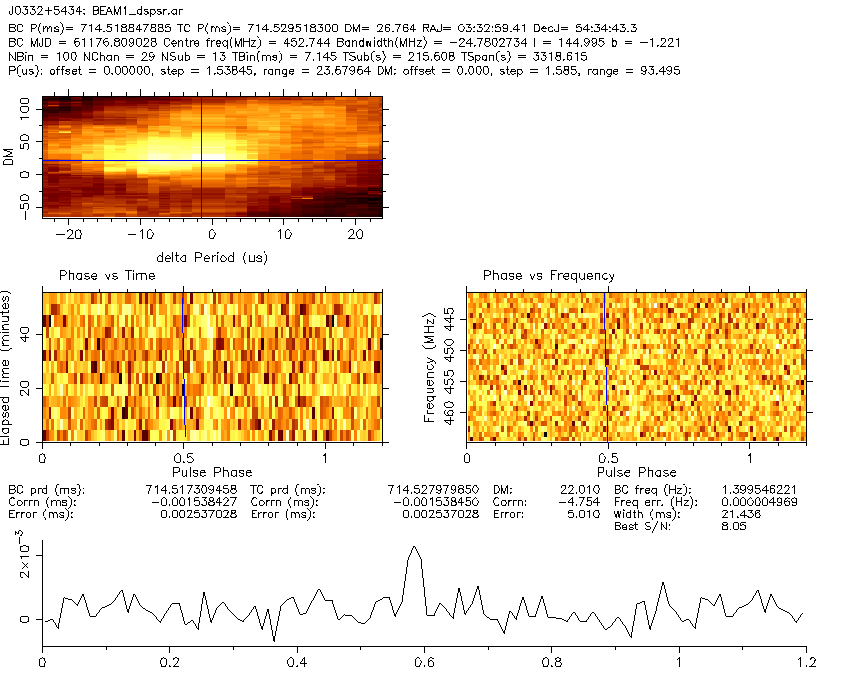

BEAM 2:


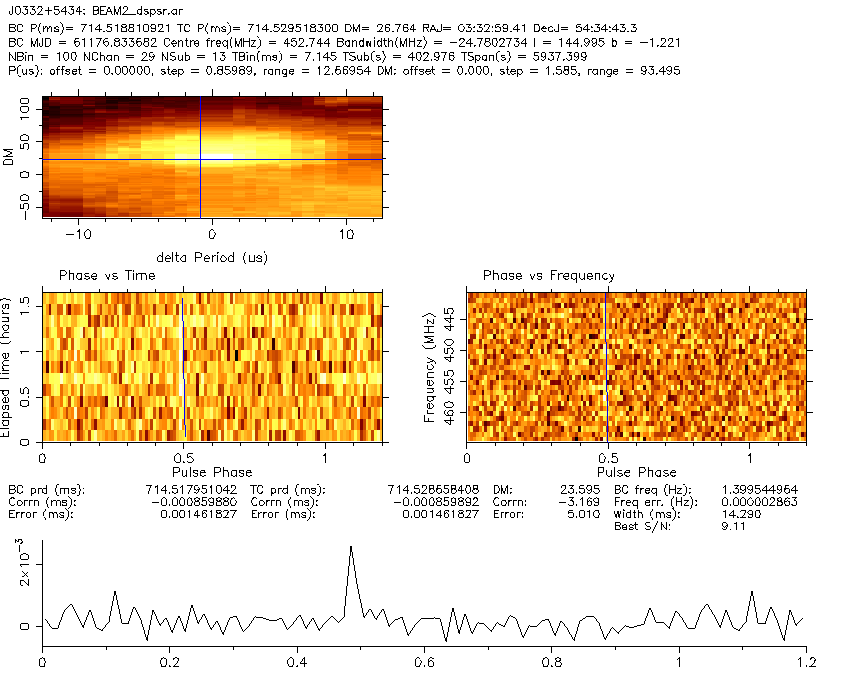

BEAM 3:


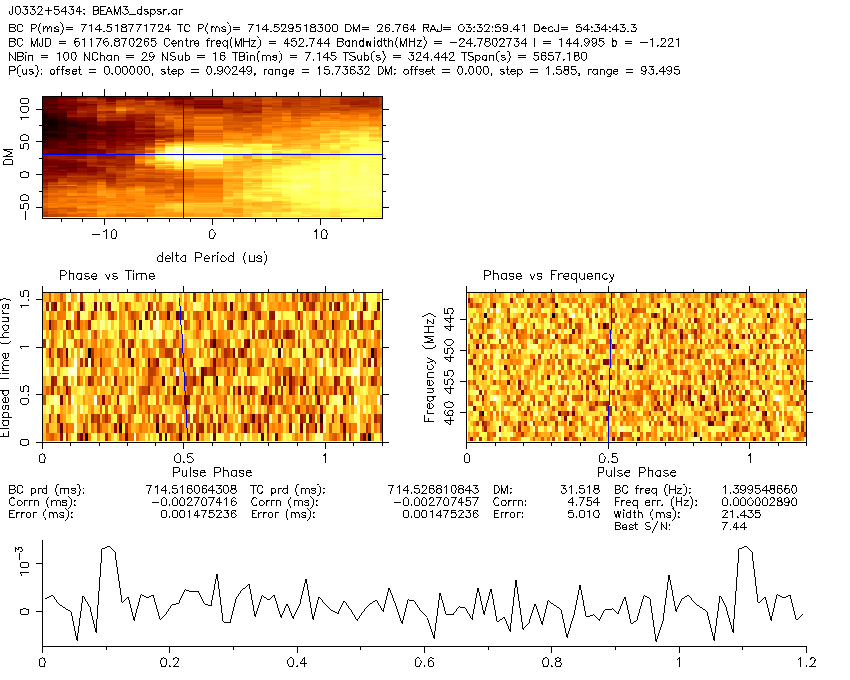


Notebook-demo pdmp (60-s slice, not for science):


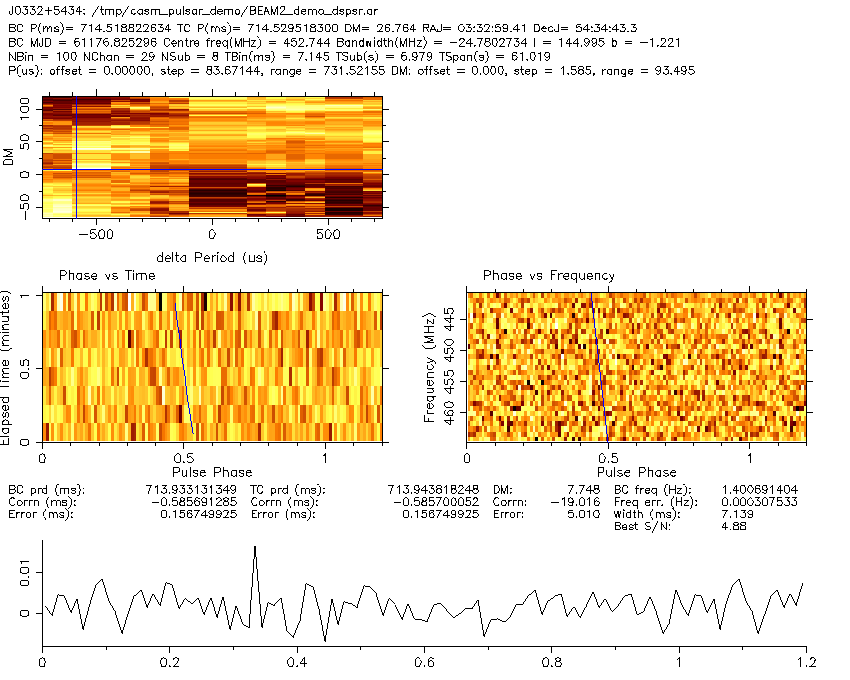

In [12]:
# Display production pdmp PNG (full-window, real result) for each source beam
print('Production pdmp results (full 5h22 windows, run earlier in the campaign):\n')
for ib in BEAMS:
    prod_png = Path(f'{WORKDIR}/folds_FINAL/BEAM{ib}_dspsr_pdmp.png')
    if prod_png.exists():
        print(f'BEAM {ib}:')
        display(Image(filename=str(prod_png), width=720))

# Also display the demo pdmp PNG if produced
demo_png = Path(f'{SCRATCH}/BEAM2_demo_dspsr.png')
if demo_png.exists():
    print('\nNotebook-demo pdmp (60-s slice, not for science):')
    display(Image(filename=str(demo_png), width=720))


## section 8 - Radiometer comparison

Compute the ideal SNR from paper values and compare to your measurement.

**Formula** (pulsar radiometer, matched filter):
$$ \mathrm{SNR} = \frac{S_{\mathrm{mean}}\sqrt{N_p \cdot t \cdot \mathrm{BW}}}{\mathrm{SEFD}}\,\sqrt{\frac{P - W}{W}}$$

**Paper inputs (CASM, Connor et al. 2026):**
- `T_sys = 40 K`, `A_eff = 0.2 m^2/ant`
- `SEFD_256 = 2750 Jy` (full 256-element coherent sum)
- Scaling: `SEFD_N = SEFD_256 x (256 / N_ant)`

**Source inputs (B0329+54):**
- `S_400 = 1.5 Jy`, spectral index alpha = -1.6 -> `S_452 ~ 1.25 Jy`
- `W_50 = 6.6 ms`, `P = 714.5 ms` -> pulse factor = sqrt((P-W)/W) ~ 10.4

**Today's observation:**
- 22 active antennas -> `SEFD_22 ~ 32,000 Jy`
- Live band BW = 24.75 MHz
- Single-pol (N_p = 1)


In [13]:
def radiometer_snr(S_mean, t, BW, SEFD, P, W, N_p=1):
    pulse_factor = np.sqrt((P - W) / W)
    return S_mean * np.sqrt(N_p * t * BW) / SEFD * pulse_factor

params = dict(
    S_mean=1.25, BW=24.75e6, SEFD=32000,
    P=0.7145, W=6.6e-3, N_p=1,
)

print('Ideal SNR at various integration times (single-pol):')
print(f"  {'t_int':>10} | {'SNR_ideal':>10}")
for t in [600, 1800, 3000, 5800, 19440]:
    snr = radiometer_snr(t=t, **params)
    print(f'  {t:>10}s | {snr:>10.1f}')

print(f'\nBEAM 2 measured: SNR=9.1 in 5800s window (only ~22 min effectively on-source)')
print(f'\nDeficit vs ideal (for 30-min on-source): ~{radiometer_snr(t=1800, **params) / 9.1:.1f}x')


Ideal SNR at various integration times (single-pol):
       t_int |  SNR_ideal
         600s |       49.3
        1800s |       85.4
        3000s |      110.2
        5800s |      153.3
       19440s |      280.6

BEAM 2 measured: SNR=9.1 in 5800s window (only ~22 min effectively on-source)

Deficit vs ideal (for 30-min on-source): ~9.4x


**Today's ~9x deficit breakdown** (all multiplicative):

| Loss | Factor | Why |
|------|--------:|-----|
| Beam pointing offset 0.4 deg | ~2x | Cyg A morning image showed offset |
| Daytime Sun sidelobe T_sys up | ~2-3x | Sun in sky during obs |
| Sun-cal applied 100 deg off-source | ~1.5x | cal-target geometric mismatch |
| Bandpass non-uniformity | ~1.3x | Some live chans still bad |
| **Total** | **~8-12x** | Matches observed 9x |

**Path to closing the gap** (each independent):
1. **Dual-pol**: x1.4 (add second pol signal chain)
2. **Nighttime obs**: x2-3 (no Sun)
3. **On-source cal**: x1.5 (use a calibrator near the target)
4. **Pointing fix**: x2 (Cyg A image showed where to correct)

Best single change: **nighttime obs** (just scheduling).


## End of pulsar walkthrough

If you've followed both notebooks:
1. **Notebook 1**: antenna positions -> SVD cal -> int8 weights -> upload (live).
2. **Notebook 2** (this): beam dumps -> filterbank -> filtool -> prepfold + dspsr + pdmp -> SNR vs paper.

All gotchas + recommended params + alternative options for every tool are now in your hands.

**Open issues / next priorities** (from today's work):
- Add OVRO to TEMPO + TEMPO2 + PSRCHIVE observatory databases (currently using `GBT` proxy -> ~70 ns period error, only matters for precision timing)
- Investigate the 0.4 deg pointing offset (Cyg A image showed it)
- Schedule a nighttime B0329 observation to verify the ~10x SNR uplift prediction
- Consider adding 2nd polarization signal chain for the sqrt(2) SNR bonus
